<a href="https://colab.research.google.com/github/Ritika-Sharma-gif/Machine-Learning-Projects/blob/main/KNN(SML)01ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd


In [8]:
df = pd.read_csv('/final.csv')

In [9]:
df.head()

,serial,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations,cases,labels
0,0,34.053151,24.478082,28.709863,39.757808,25.317808,32.306301,22.971233,73.508219,2.921726,...,1007.911781,50.747945,3.789863,208.097808,17.973699,7.232877,2.558904,1.197260,4925.0,normal
1,1,34.086179,25.694309,29.464228,41.338211,28.140650,34.423577,23.484553,72.066667,3.783415,...,1003.533333,48.313821,2.884553,222.926016,19.246341,7.504065,1.658537,0.991870,5077.0,normal
2,2,34.573984,25.417886,29.526829,40.464228,26.560163,33.085366,22.580488,69.424390,3.065854,...,1005.731707,55.621138,4.242276,229.413008,19.802439,7.829268,1.910569,1.170732,7579.0,normal
3,3,33.020325,25.080488,28.727642,37.878049,26.193496,31.772358,21.752033,69.297561,6.025203,...,1003.359350,50.208130,2.991057,225.421951,19.480488,7.593496,1.300813,0.146341,13706.0,normal
4,4,30.660976,24.230894,26.774797,36.586992,24.263415,28.943902,24.214634,86.652033,23.336585,...,1009.995935,45.542276,3.886992,176.598374,15.261789,6.186992,0.967480,3.951220,82.0,normal


In [10]:
df.shape

(602, 26)

In [11]:
df.columns

Index(['serial', 'tempmax', 'tempmin', 'temp', 'feelslikemax', 'feelslikemin',
       'feelslike', 'dew', 'humidity', 'precip', 'precipprob', 'precipcover',
       'snow', 'snowdepth', 'windspeed', 'winddir', 'sealevelpressure',
       'cloudcover', 'visibility', 'solarradiation', 'solarenergy', 'uvindex',
       'conditions', 'stations', 'cases', 'labels'],
      dtype='object')

In [12]:
df.tail()

,serial,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,stations,cases,labels
597,597,32.3,24.4,28.5,35.9,24.4,31.2,23.3,75.0,0.0,...,1008.9,50.4,3.1,252.5,21.9,9.0,1.0,1.0,6729.0,normal
598,598,32.7,26.4,29.3,36.3,26.4,32.5,22.6,68.5,0.0,...,1010.4,50.5,3.1,242.7,20.9,8.0,1.0,1.0,10541.0,normal
599,599,33.0,26.3,29.8,40.5,26.3,34.5,23.9,71.1,0.0,...,1010.8,30.5,3.1,195.3,16.9,8.0,1.0,1.0,6396.0,normal
600,600,35.1,26.8,30.6,42.9,29.1,35.1,23.3,65.9,0.0,...,1009.7,32.7,3.3,187.6,16.0,7.0,1.0,1.0,10883.0,normal
601,601,34.0,26.3,30.2,38.1,26.3,33.1,21.5,60.4,0.0,...,1008.7,46.5,3.9,136.2,11.7,5.0,1.0,1.0,7311.0,normal


In [14]:
df_cleaned = df.dropna()

In [15]:
df_cleaned = df_cleaned.drop(columns=['serial'])

In [16]:
print(f"Original row: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")

Original row: 602
Cleaned rows: 602


In [17]:
df.describe

<bound method NDFrame.describe of      serial    tempmax    tempmin       temp  feelslikemax  feelslikemin  \
0         0  34.053151  24.478082  28.709863     39.757808     25.317808   
1         1  34.086179  25.694309  29.464228     41.338211     28.140650   
2         2  34.573984  25.417886  29.526829     40.464228     26.560163   
3         3  33.020325  25.080488  28.727642     37.878049     26.193496   
4         4  30.660976  24.230894  26.774797     36.586992     24.263415   
..      ...        ...        ...        ...           ...           ...   
597     597  32.300000  24.400000  28.500000     35.900000     24.400000   
598     598  32.700000  26.400000  29.300000     36.300000     26.400000   
599     599  33.000000  26.300000  29.800000     40.500000     26.300000   
600     600  35.100000  26.800000  30.600000     42.900000     29.100000   
601     601  34.000000  26.300000  30.200000     38.100000     26.300000   

     feelslike        dew   humidity     precip  ...  sealevelpressure  \
0    32.306301  22.971233  73.508219   2.921726  ...       1007.911781   
1    34.423577  23.484553  72.066667   3.783415  ...       1003.533333   
2    33.085366  22.580488  69.424390   3.065854  ...       1005.731707   
3    31.772358  21.752033  69.297561   6.025203  ...       1003.359350   
4    28.943902  24.214634  86.652033  23.336585  ...       1009.995935   
..         ...        ...        ...        ...  ...               ...   
597  31.200000  23.300000  75.000000   0.000000  ...       1008.900000   
598  32.500000  22.600000  68.500000   0.000000  ...       1010.400000   
599  34.500000  23.900000  71.100000   0.000000  ...       1010.800000   
600  35.100000  23.300000  65.900000   0.000000  ...       1009.700000   
601  33.100000  21.500000  60.400000   0.000000  ...       1008.700000   

     cloudcover  visibility  solarradiation  solarenergy   uvindex  \
0     50.747945    3.789863      208.097808    17.973699  7.232877   
1     48.313821    2.884553      222.926016    19.246341  7.504065   
2     55.621138    4.242276      229.413008    19.802439  7.829268   
3     50.208130    2.991057      225.421951    19.480488  7.593496   
4     45.542276    3.886992      176.598374    15.261789  6.186992   
..          ...         ...             ...          ...       ...   
597   50.400000    3.100000      252.500000    21.900000  9.000000   
598   50.500000    3.100000      242.700000    20.900000  8.000000   
599   30.500000    3.100000      195.300000    16.900000  8.000000   
600   32.700000    3.300000      187.600000    16.000000  7.000000   
601   46.500000    3.900000      136.200000    11.700000  5.000000   

     conditions  stations    cases  labels  
0      2.558904  1.197260   4925.0  normal  
1      1.658537  0.991870   5077.0  normal  
2      1.910569  1.170732   7579.0  normal  
3      1.300813  0.146341  13706.0  normal  
4      0.967480  3.951220     82.0  normal  
..          ...       ...      ...     ...  
597    1.000000  1.000000   6729.0  normal  
598    1.000000  1.000000  10541.0  normal  
599    1.000000  1.000000   6396.0  normal  
600    1.000000  1.000000  10883.0  normal  
601    1.000000  1.000000   7311.0  normal  

[602 rows x 26 columns]>

In [21]:

X = df_cleaned.drop(columns=['labels'])


y = df_cleaned['labels']


print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (602, 24)
Target (y) shape: (602,)


In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print("Training data features (X_train): ", X_train.shape)
print("Testing data features(X_test): ", X_test.shape)

Training data features (X_train):  (481, 24)
Testing data features(X_test):  (121, 24)


In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.fit_transform(X_test)


print("Before scaling:\n", X_train.iloc[0].values)
print("\nAfter scaling\n", X_train_scaled[0])

Before scaling:
 [3.07691057e+01 2.30666667e+01 2.63138211e+01 3.63577236e+01
 2.30666667e+01 2.81146341e+01 2.40658537e+01 8.83902439e+01
 1.15975610e+01 9.18699187e+01 1.73124390e+01 0.00000000e+00
 0.00000000e+00 1.00934959e+01 1.69942276e+02 1.01014309e+03
 7.85975610e+01 3.72276423e+00 2.08988618e+02 1.80479675e+01
 7.38211382e+00 2.42276423e+00 7.64227642e-01 1.50000000e+02]

After scaling
 [-0.41591658 -0.52956861 -0.60119357 -0.43944977 -0.58591243 -0.71158322
  0.04388933  0.76091172 -0.06691506  0.48847845  0.5519264   0.
  0.         -0.84778023 -0.25473471  0.12475431  0.90820886  0.02368547
  0.20274146  0.20357136  0.32177373  0.49994968 -0.09761237 -1.24080202]


In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("Model training complete!")

Model training complete!


In [25]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_test)
print(f"Overall Accuracy : {accuracy * 100 :.2f}%\n")


print("Detailed Report: ")
print(classification_report(y_test, y_pred))

Overall Accuracy : 100.00%

Detailed Report: 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       121

    accuracy                           1.00       121
   macro avg       1.00      1.00      1.00       121
weighted avg       1.00      1.00      1.00       121



In [33]:
new_weather_data = X_test.iloc[[0]]

print("The new wheather numbers are: ")
print(new_weather_data.values)

new_weather_scaled = scaler.transform(new_weather_data)


prediction = knn.predict(new_weather_scaled)

print(f"\n---> The model predicts this weather is : {prediction[0]}")

The new wheather numbers are: 
[[3.0000e+01 1.8600e+01 2.3000e+01 3.2800e+01 1.8600e+01 2.3200e+01
  1.7100e+01 7.1300e+01 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
  0.0000e+00 8.3000e+00 3.3100e+01 1.0105e+03 8.6000e+00 2.6000e+00
  2.3830e+02 2.0700e+01 8.0000e+00 0.0000e+00 0.0000e+00 2.8980e+03]]

---> The model predicts this weather is : normal


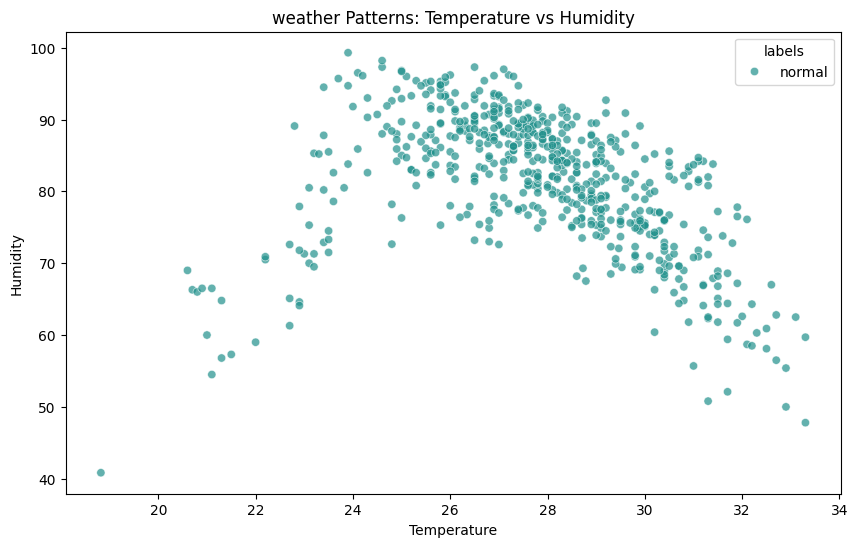

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data = df_cleaned,
    x='temp',
    y='humidity',
    hue='labels' ,
    palette='viridis',
    alpha=0.7
)

plt.title('weather Patterns: Temperature vs Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')

plt.show()